HFSS band: 10.0 MHz → 14.99 GHz
Hermitian check: True
Output peak at: 1.161 ns
Output peak amplitude: 36.795+0.000j


c:\Users\Gauri Korgaonkar\AppData\Local\Programs\Python\Python314\Lib\site-packages\matplotlib\cbook.py:1719: ComplexWarning: Casting complex values to real discards the imaginary part
  return math.isfinite(val)
c:\Users\Gauri Korgaonkar\AppData\Local\Programs\Python\Python314\Lib\site-packages\matplotlib\cbook.py:1355: ComplexWarning: Casting complex values to real discards the imaginary part
  return np.asarray(x, float)


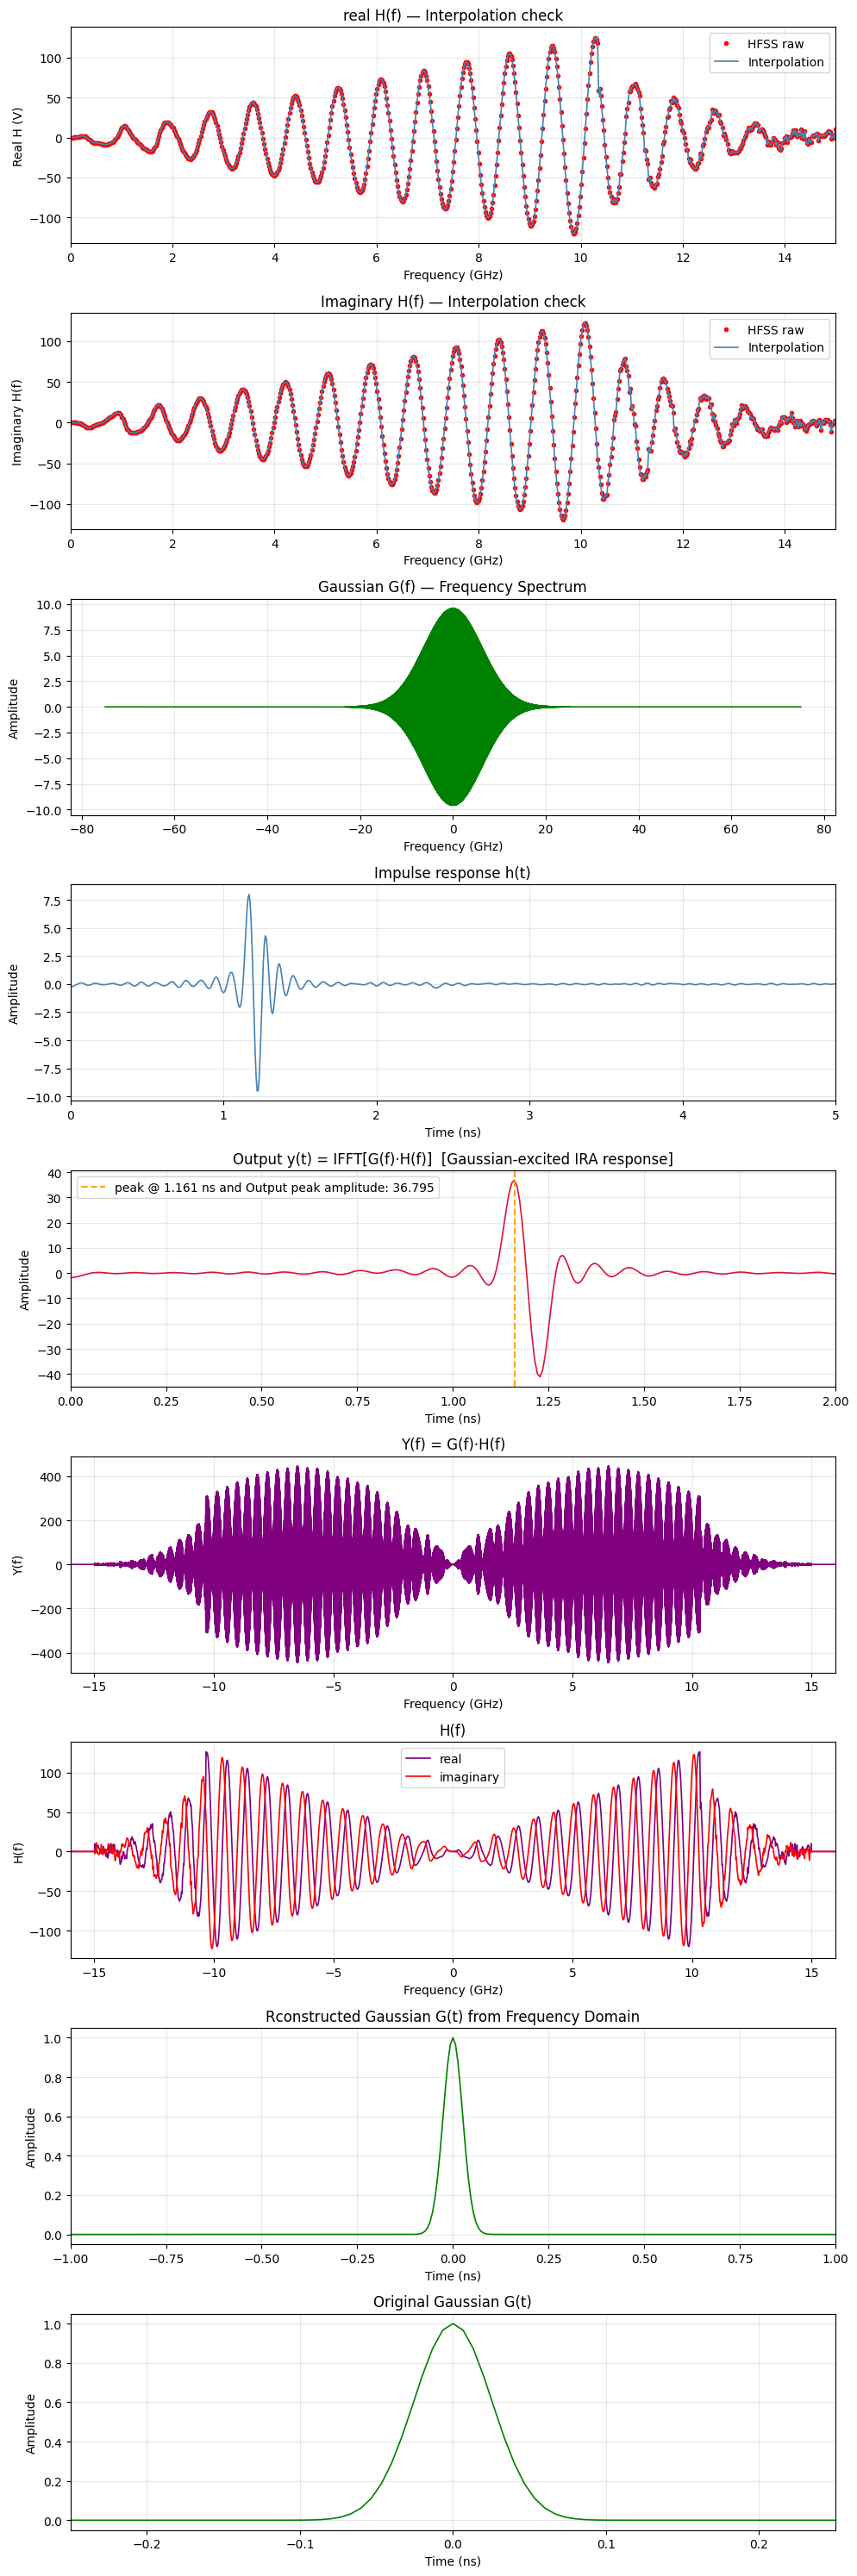

In [1]:
import numpy as np
import pandas as pd
from scipy.interpolate import CubicSpline
from scipy.signal.windows import hann
import matplotlib.pyplot as plt

# ── 1. LOAD HFSS DATA ─────────────────────────────────────────
df = pd.read_csv(r'C:\Shakthi\Shakthi_HFSS\rE Plot 1_server.csv')

freq_raw = df['Freq [GHz]'].values * 1e9
mag_raw  = df['re(rEPhi) [V]'].values
phs_raw  = df['im(rEPhi) [V]'].values

f_min = freq_raw[0]
f_max = freq_raw[-1]
print(f"HFSS band: {f_min/1e6:.1f} MHz → {f_max/1e9:.2f} GHz")

# ── 1. PARAMETERS ─────────────────────────────────────────────
f_center = (f_max + f_min) / 2.0    # ~7.505 GHz

# ── 2. FFT GRID ───────────────────────────────────────────────

N = 2**16

# 1. Define Pulse Parameters
fwhm = 0.06e-9           # Pulse width (60 ps)
center_time = 0e-9   # Centered pulse

# 2. Calculate Sigma from FWHM

sigma = fwhm / (2 * np.sqrt(2 * np.log(2)))  # Formula: sigma = FWHM / (2 * sqrt(2 * ln(2)))

# 3. Create Time Domain Signal

fs  = 10.0 * f_max           # sampling rate with headroom
dt  = 1.0 / fs
df  = fs / N
t   = (np.arange(N) - N//2) * dt     # centered time axis
t_ns  = t * 1e9

# 4. Generate Gaussian Pulse

pulse = np.exp(-0.5 * ((t - center_time) / sigma)**2)  # Pulse formula: exp(-0.5 * ((t - t0) / sigma)^2)

# T = 0.25e-09
# t0 = 5e-09
# gamma = (4/T)*(t-t0)
# pulse = np.exp(-gamma**2)

gauss_f = np.fft.fft(pulse)
f_freq = np.fft.fftfreq(N, dt)

# ── 3. INTERPOLATE H(f) ONTO FFT GRID ────────────────────────
interp_mag = CubicSpline(freq_raw, mag_raw)
interp_phs = CubicSpline(freq_raw, phs_raw)

mag_H = np.zeros(N)
phs_H = np.zeros(N)
mask_pos = (f_freq >= f_min) & (f_freq <= f_max)
pos_idx  = np.where(mask_pos)[0]

mag_H[mask_pos] = interp_mag(f_freq[mask_pos])
phs_H[mask_pos] = interp_phs(f_freq[mask_pos])


# ── 5. BUILD HERMITIAN H(f) ──────────────────────────────────
H = np.zeros(N, dtype=complex)
H[pos_idx] = mag_H[pos_idx] + 1j * phs_H[pos_idx]

for k in pos_idx:
    if k == 0 or (N % 2 == 0 and k == N // 2):
        continue
    H[-k] = np.conj(H[k])

H[0] = H[0].real
if N % 2 == 0:
    H[N//2] = H[N//2].real

print("Hermitian check:", np.allclose(H[1:N//2], np.conj(H[-1:N//2:-1])))


#Time domain response

G_time = np.fft.ifft(gauss_f)

# ── 7. OUTPUT: Y(f) = G(f) * H(f) → IFFT ────────────────────
Y   = gauss_f * H
y_t = np.fft.ifft(Y)

# ── 8. IMPULSE RESPONSE ──────────────────────────────────────
h_t = np.fft.fftshift(np.fft.ifft(H))


peak_idx = np.argmax((y_t))
print(f"Output peak at: {t_ns[peak_idx]:.3f} ns")
print(f"Output peak amplitude: {y_t[peak_idx]:.3f}")

# ── 10. PLOTS ────────────────────────────────────────────────
fig, axes = plt.subplots(9, 1, figsize=(10, 30))

axes[0].plot(freq_raw/1e9, mag_raw, 'o', ms=3, color='red', label='HFSS raw')
axes[0].plot(np.fft.fftshift(f_freq)/1e9, np.fft.fftshift(mag_H), lw=1.2, color='steelblue',label='Interpolation')
axes[0].set_title("real H(f) — Interpolation check")
axes[0].set_xlabel("Frequency (GHz)"); axes[0].set_ylabel("Real H (V)")
axes[0].set_xlim(0, f_max/1e9); axes[0].legend(); axes[0].grid(True, alpha=0.3)

axes[1].plot(freq_raw/1e9, phs_raw, 'o', ms=3, color='red', label='HFSS raw')
axes[1].plot(np.fft.fftshift(f_freq)/1e9, np.fft.fftshift(phs_H), lw=1.2, color='steelblue',label='Interpolation')
axes[1].set_title("Imaginary H(f) — Interpolation check")
axes[1].set_xlabel("Frequency (GHz)"); axes[1].set_ylabel("Imaginary H(f)")
axes[1].set_xlim(0, f_max/1e9); axes[1].legend(); axes[1].grid(True, alpha=0.3)

axes[2].plot(np.fft.fftshift(f_freq)/1e9,np.fft.fftshift(gauss_f), color='green', lw=1.2)
axes[2].set_title("Gaussian G(f) — Frequency Spectrum")
axes[2].set_xlabel("Frequency (GHz)"); axes[2].set_ylabel("Amplitude")
axes[2].grid(True, alpha=0.3)
# axes[2].set_xlim(-20, 20)

axes[3].plot(t_ns, h_t, color='steelblue', lw=1.2)
axes[3].set_title("Impulse response h(t)")
axes[3].set_xlabel("Time (ns)"); axes[3].set_ylabel("Amplitude")
axes[3].grid(True, alpha=0.3)
axes[3].set_xlim(0,5)

axes[4].plot(t_ns, y_t, color='crimson', lw=1.2)
axes[4].axvline(t_ns[peak_idx], color='orange', ls='--',label=f'peak @ {t_ns[peak_idx]:.3f} ns and Output peak amplitude: {np.abs(y_t[peak_idx]):.3f}')
axes[4].set_title("Output y(t) = IFFT[G(f)·H(f)]  [Gaussian-excited IRA response]")
axes[4].set_xlabel("Time (ns)"); axes[4].set_ylabel("Amplitude")
axes[4].set_xlim(0, 2)
axes[4].legend(); axes[4].grid(True, alpha=0.3)

axes[5].plot(np.fft.fftshift(f_freq)/1e9,np.fft.fftshift(Y), color='purple', lw=1.2)
axes[5].set_title("Y(f) = G(f)·H(f)")
axes[5].set_xlabel("Frequency (GHz)"); axes[5].set_ylabel("Y(f)")
axes[5].grid(True, alpha=0.3)
axes[5].set_xlim(-16,16)

axes[6].plot(np.fft.fftshift(f_freq)/1e9,np.fft.fftshift(H.real), color='purple', lw=1.2, label = 'real')
axes[6].plot(np.fft.fftshift(f_freq)/1e9,np.fft.fftshift(H.imag), color='red', lw=1.2, label = 'imaginary')
axes[6].set_title("H(f)")
axes[6].set_xlabel("Frequency (GHz)"); axes[6].set_ylabel("H(f)")
axes[6].grid(True, alpha=0.3)
axes[6].legend(loc='upper center')
axes[6].set_xlim(-16,16)

axes[7].plot(t_ns, G_time, color='green', lw=1.2)
axes[7].set_title("Rconstructed Gaussian G(t) from Frequency Domain")
axes[7].set_xlabel("Time (ns)"); axes[7].set_ylabel("Amplitude")
axes[7].grid(True, alpha=0.3)
axes[7].set_xlim(-1,1)

axes[8].plot(t_ns, pulse, color='green', lw=1.2)
axes[8].set_title("Original Gaussian G(t)")
axes[8].set_xlabel("Time (ns)"); axes[8].set_ylabel("Amplitude")
axes[8].grid(True, alpha=0.3)
axes[8].set_xlim(-0.25,0.25)


plt.tight_layout()
# plt.savefig("C:\Shakthi\Shakthi_HFSS\IRA_gaussian_time_domain.png", dpi=1080)
plt.show()

HFSS band: 10.0 MHz → 14.99 GHz
Hermitian check: True
Output peak at: 1.194 ns
Output peak amplitude: 93.672-0.000j


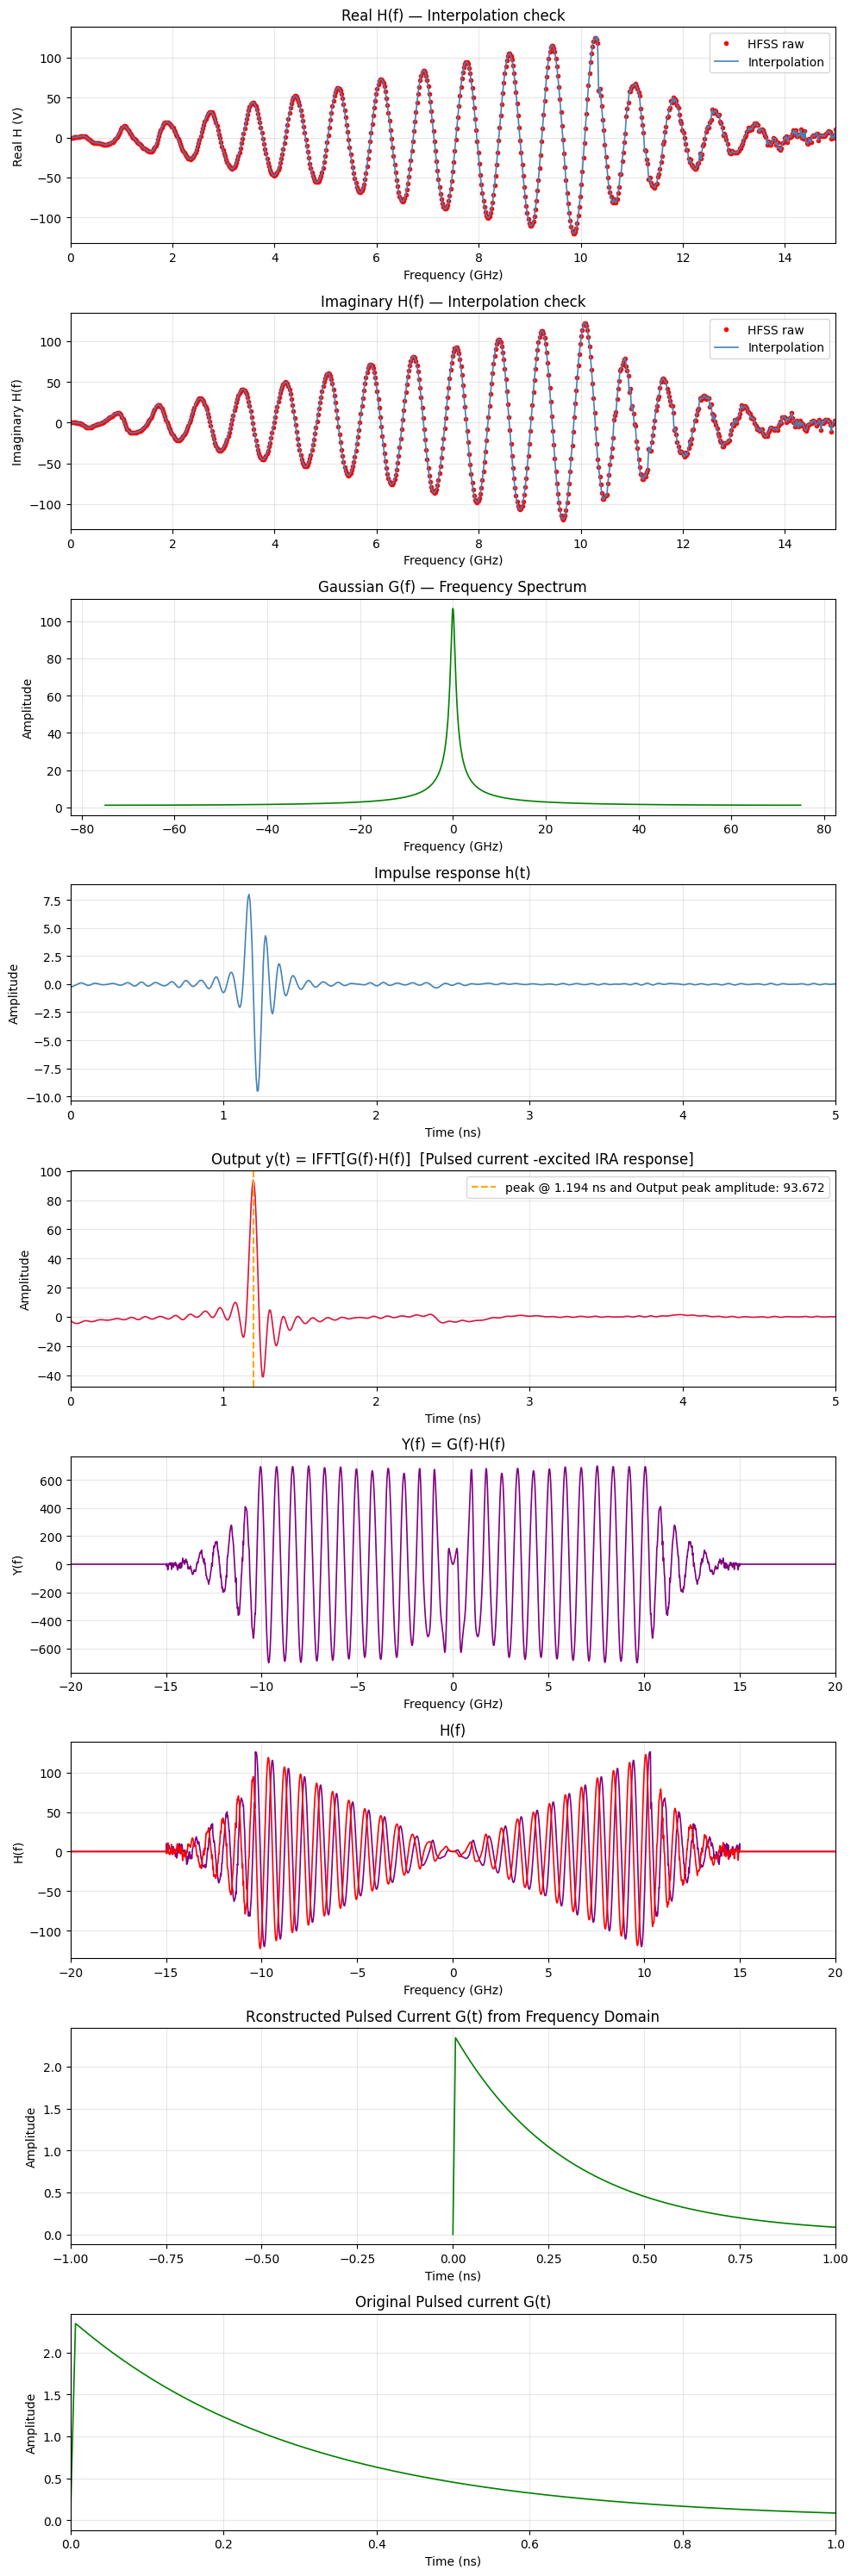

In [ ]:
import numpy as np
import pandas as pd
from scipy.interpolate import CubicSpline
from scipy.signal.windows import hann
import matplotlib.pyplot as plt

# ── 1. LOAD HFSS DATA ─────────────────────────────────────────
df = pd.read_csv(r'C:\Shakthi\Shakthi_HFSS\rE Plot 1_server.csv')

freq_raw = df['Freq [GHz]'].values * 1e9
mag_raw  = df['re(rEPhi) [V]'].values
phs_raw  = df['im(rEPhi) [V]'].values

f_min = freq_raw[0]
f_max = freq_raw[-1]
print(f"HFSS band: {f_min/1e6:.1f} MHz → {f_max/1e9:.2f} GHz")

# ── 1. PARAMETERS ─────────────────────────────────────────────
f_center = (f_max + f_min) / 2.0    # ~7.505 GHz

# ── 2. FFT GRID ───────────────────────────────────────────────

N = 2**16

# 1. Define Pulse Parameters
t_rise = 1e-12           # Rise time (1 ps)
t_fall = 300e-12         # Fall time (300 ps)
center_time = 0e-9   # Centered pulse
fs  = 10.0 * f_max           # sampling rate with headroom
dt  = 1.0 / fs
df  = fs / N

t   = (np.arange(N)) * dt     # centered time axis
t_ns  = t * 1e9

# 4. Generate Gaussian Pulse

t1 = np.exp(-t/t_fall)
t2 = np.exp(-t/t_rise)
pulsed_current = (t1-t2)*2.4

gauss_f = np.fft.fft(pulsed_current)
f_freq = np.fft.fftfreq(N, dt)

# ── 3. INTERPOLATE H(f) ONTO FFT GRID ────────────────────────
interp_mag = CubicSpline(freq_raw, mag_raw)
interp_phs = CubicSpline(freq_raw, phs_raw)

mag_H = np.zeros(N)
phs_H = np.zeros(N)
mask_pos = (f_freq >= f_min) & (f_freq <= f_max)
pos_idx  = np.where(mask_pos)[0]

mag_H[mask_pos] = interp_mag(f_freq[mask_pos])
phs_H[mask_pos] = interp_phs(f_freq[mask_pos])


# ── 5. BUILD HERMITIAN H(f) ──────────────────────────────────
H = np.zeros(N, dtype=complex)
H[pos_idx] = mag_H[pos_idx] + 1j * phs_H[pos_idx]

for k in pos_idx:
    if k == 0 or (N % 2 == 0 and k == N // 2):
        continue
    H[-k] = np.conj(H[k])

H[0] = H[0].real
if N % 2 == 0:
    H[N//2] = H[N//2].real

print("Hermitian check:", np.allclose(H[1:N//2], np.conj(H[-1:N//2:-1])))

#Time domain response

G_time = np.fft.ifft(gauss_f)

# ── 7. OUTPUT: Y(f) = G(f) * H(f) → IFFT ────────────────────
Y   = gauss_f * H
y_t = np.fft.ifft(Y)

# ── 8. IMPULSE RESPONSE ──────────────────────────────────────
h_t = np.fft.ifft(H)

peak_idx = np.argmax((y_t))
print(f"Output peak at: {t_ns[peak_idx]:.3f} ns")
print(f"Output peak amplitude: {y_t[peak_idx]:.3f}")

# ── 10. PLOTS ────────────────────────────────────────────────
fig, axes = plt.subplots(9, 1, figsize=(10, 30))

axes[0].plot(freq_raw/1e9, mag_raw, 'o', ms=3, color='red', label='HFSS raw')
axes[0].plot(np.fft.fftshift(f_freq)/1e9, np.fft.fftshift(mag_H), lw=1.2, color='steelblue',label='Interpolation')
axes[0].set_title("Real H(f) — Interpolation check")
axes[0].set_xlabel("Frequency (GHz)"); axes[0].set_ylabel("Real H (V)")
axes[0].set_xlim(0, f_max/1e9); axes[0].legend(); axes[0].grid(True, alpha=0.3)

axes[1].plot(freq_raw/1e9, phs_raw, 'o', ms=3, color='red', label='HFSS raw')
axes[1].plot(np.fft.fftshift(f_freq)/1e9, np.fft.fftshift(phs_H), lw=1.2, color='steelblue',label='Interpolation')
axes[1].set_title("Imaginary H(f) — Interpolation check")
axes[1].set_xlabel("Frequency (GHz)"); axes[1].set_ylabel("Imaginary H(f)")
axes[1].set_xlim(0, f_max/1e9); axes[1].legend(); axes[1].grid(True, alpha=0.3)

axes[2].plot(np.fft.fftshift(f_freq)/1e9,np.fft.fftshift(np.abs(gauss_f)), color='green', lw=1.2)
axes[2].set_title("Gaussian G(f) — Frequency Spectrum")
axes[2].set_xlabel("Frequency (GHz)"); axes[2].set_ylabel("Amplitude")
axes[2].grid(True, alpha=0.3)
# axes[2].set_xlim(-0.1, 0.1)

axes[3].plot(t_ns, h_t, color='steelblue', lw=1.2)
axes[3].set_title("Impulse response h(t)")
axes[3].set_xlabel("Time (ns)"); axes[3].set_ylabel("Amplitude")
axes[3].grid(True, alpha=0.3)
axes[3].set_xlim(0,5)

axes[4].plot(t_ns, y_t, color='crimson', lw=1.2)
axes[4].axvline(t_ns[peak_idx], color='orange', ls='--',label=f'peak @ {t_ns[peak_idx]:.3f} ns and Output peak amplitude: {np.abs(y_t[peak_idx]):.3f}')
axes[4].set_title("Output y(t) = IFFT[G(f)·H(f)]  [Pulsed current -excited IRA response]")
axes[4].set_xlabel("Time (ns)"); axes[4].set_ylabel("Amplitude")
axes[4].set_xlim(0, 5)
axes[4].legend(); axes[4].grid(True, alpha=0.3)

axes[5].plot(np.fft.fftshift(f_freq)/1e9,np.fft.fftshift(Y), color='purple', lw=1.2)
axes[5].set_title("Y(f) = G(f)·H(f)")
axes[5].set_xlabel("Frequency (GHz)"); axes[5].set_ylabel("Y(f)")
axes[5].grid(True, alpha=0.3)
axes[5].set_xlim(-20, 20)

axes[6].plot(np.fft.fftshift(f_freq)/1e9,np.fft.fftshift(H.real), color='purple', lw=1.2, label='real')
axes[6].plot(np.fft.fftshift(f_freq)/1e9,np.fft.fftshift(H.imag), color='red', lw=1.2, label='imaginary')
axes[6].set_title("H(f)")
axes[6].set_xlabel("Frequency (GHz)"); axes[6].set_ylabel("H(f)")
axes[6].grid(True, alpha=0.3)
axes[6].set_xlim(-20, 20)

axes[7].plot(t_ns, G_time, color='green', lw=1.2)
axes[7].set_title("Rconstructed Pulsed Current G(t) from Frequency Domain")
axes[7].set_xlabel("Time (ns)"); axes[7].set_ylabel("Amplitude")
axes[7].grid(True, alpha=0.3)
axes[7].set_xlim(-1,1)

axes[8].plot(t_ns, pulsed_current, color='green', lw=1.2)
axes[8].set_title("Original Pulsed current G(t)")
axes[8].set_xlabel("Time (ns)"); axes[8].set_ylabel("Amplitude")
axes[8].grid(True, alpha=0.3)
axes[8].set_xlim(0,1)


plt.tight_layout()
# plt.savefig("C:\Shakthi\Shakthi_HFSS\IRA_time_domain.png", dpi=1080)
plt.show()

HFSS band: 10.0 MHz → 15.00 GHz
Hermitian check: True
Output peak at: 1.160 ns
Output peak amplitude: 44.139+0.000j


c:\Users\Gauri Korgaonkar\AppData\Local\Programs\Python\Python314\Lib\site-packages\matplotlib\cbook.py:1719: ComplexWarning: Casting complex values to real discards the imaginary part
  return math.isfinite(val)
c:\Users\Gauri Korgaonkar\AppData\Local\Programs\Python\Python314\Lib\site-packages\matplotlib\cbook.py:1355: ComplexWarning: Casting complex values to real discards the imaginary part
  return np.asarray(x, float)


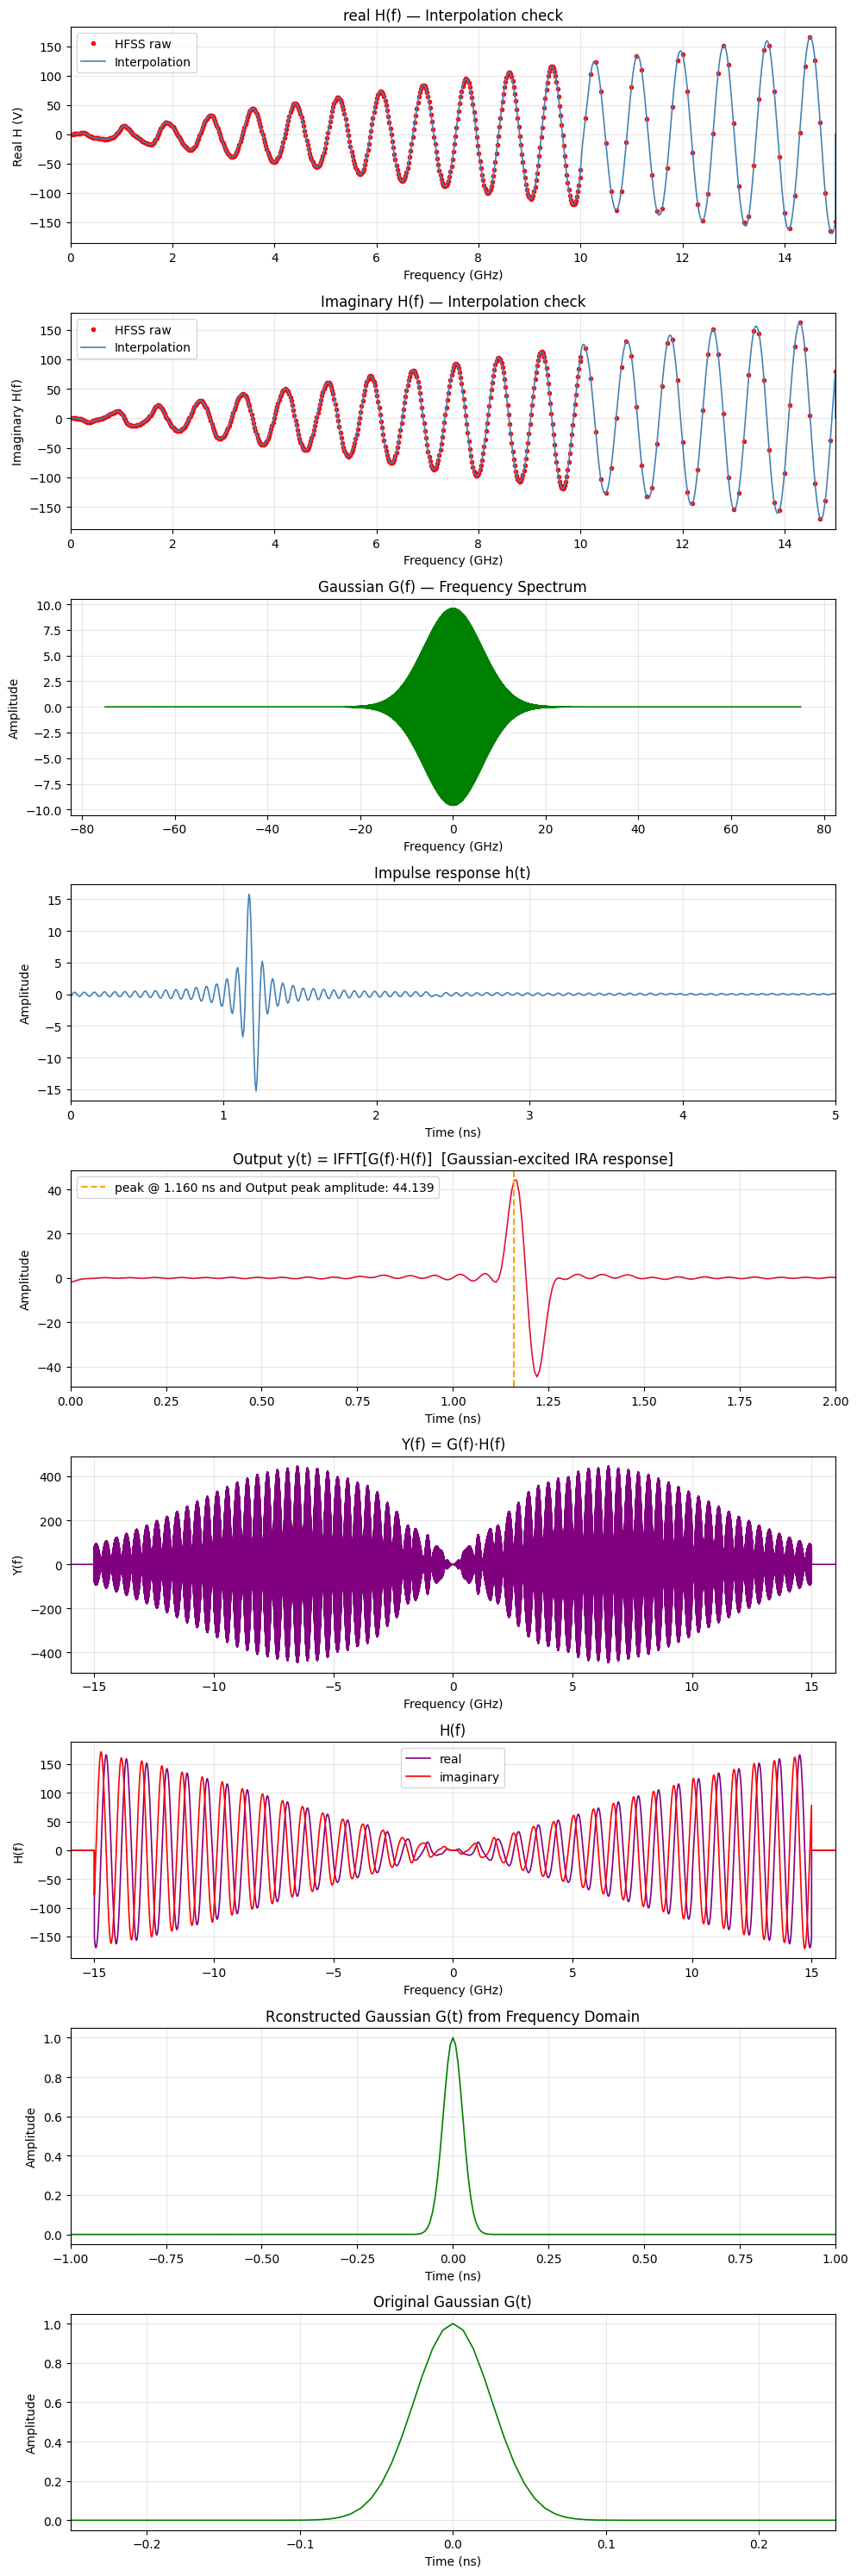

In [1]:
import numpy as np
import pandas as pd
from scipy.interpolate import CubicSpline
from scipy.signal.windows import hann
import matplotlib.pyplot as plt

# ── 1. LOAD HFSS DATA ─────────────────────────────────────────
df = pd.read_csv(r'C:\Shakthi\Shakthi_HFSS\rE Plot 1_server_combined.csv')

freq_raw = df['Freq [GHz]'].values * 1e9
mag_raw  = df['re(rEPhi) [V]'].values
phs_raw  = df['im(rEPhi) [V]'].values

f_min = freq_raw[0]
f_max = freq_raw[-1]
print(f"HFSS band: {f_min/1e6:.1f} MHz → {f_max/1e9:.2f} GHz")

# ── 1. PARAMETERS ─────────────────────────────────────────────
f_center = (f_max + f_min) / 2.0    # ~7.505 GHz

# ── 2. FFT GRID ───────────────────────────────────────────────

N = 2**16

# 1. Define Pulse Parameters
fwhm = 0.06e-9           # Pulse width (60 ps)
center_time = 0e-9   # Centered pulse

# 2. Calculate Sigma from FWHM

sigma = fwhm / (2 * np.sqrt(2 * np.log(2)))  # Formula: sigma = FWHM / (2 * sqrt(2 * ln(2)))

# 3. Create Time Domain Signal

fs  = 10.0 * f_max           # sampling rate with headroom
dt  = 1.0 / fs
df  = fs / N
t   = (np.arange(N) - N//2) * dt     # centered time axis
t_ns  = t * 1e9

# 4. Generate Gaussian Pulse

pulse = np.exp(-0.5 * ((t - center_time) / sigma)**2)  # Pulse formula: exp(-0.5 * ((t - t0) / sigma)^2)

# T = 0.25e-09
# t0 = 5e-09
# gamma = (4/T)*(t-t0)
# pulse = np.exp(-gamma**2)

gauss_f = np.fft.fft(pulse)
f_freq = np.fft.fftfreq(N, dt)

# ── 3. INTERPOLATE H(f) ONTO FFT GRID ────────────────────────
interp_mag = CubicSpline(freq_raw, mag_raw)
interp_phs = CubicSpline(freq_raw, phs_raw)

mag_H = np.zeros(N)
phs_H = np.zeros(N)
mask_pos = (f_freq >= f_min) & (f_freq <= f_max)
pos_idx  = np.where(mask_pos)[0]

mag_H[mask_pos] = interp_mag(f_freq[mask_pos])
phs_H[mask_pos] = interp_phs(f_freq[mask_pos])


# ── 5. BUILD HERMITIAN H(f) ──────────────────────────────────
H = np.zeros(N, dtype=complex)
H[pos_idx] = mag_H[pos_idx] + 1j * phs_H[pos_idx]

for k in pos_idx:
    if k == 0 or (N % 2 == 0 and k == N // 2):
        continue
    H[-k] = np.conj(H[k])

H[0] = H[0].real
if N % 2 == 0:
    H[N//2] = H[N//2].real

print("Hermitian check:", np.allclose(H[1:N//2], np.conj(H[-1:N//2:-1])))


#Time domain response

G_time = np.fft.ifft(gauss_f)

# ── 7. OUTPUT: Y(f) = G(f) * H(f) → IFFT ────────────────────
Y   = gauss_f * H
y_t = np.fft.ifft(Y)

# ── 8. IMPULSE RESPONSE ──────────────────────────────────────
h_t = np.fft.fftshift(np.fft.ifft(H))


peak_idx = np.argmax((y_t))
print(f"Output peak at: {t_ns[peak_idx]:.3f} ns")
print(f"Output peak amplitude: {y_t[peak_idx]:.3f}")

# ── 10. PLOTS ────────────────────────────────────────────────
fig, axes = plt.subplots(9, 1, figsize=(10, 30))

axes[0].plot(freq_raw/1e9, mag_raw, 'o', ms=3, color='red', label='HFSS raw')
axes[0].plot(np.fft.fftshift(f_freq)/1e9, np.fft.fftshift(mag_H), lw=1.2, color='steelblue',label='Interpolation')
axes[0].set_title("real H(f) — Interpolation check")
axes[0].set_xlabel("Frequency (GHz)"); axes[0].set_ylabel("Real H (V)")
axes[0].set_xlim(0, f_max/1e9); axes[0].legend(); axes[0].grid(True, alpha=0.3)

axes[1].plot(freq_raw/1e9, phs_raw, 'o', ms=3, color='red', label='HFSS raw')
axes[1].plot(np.fft.fftshift(f_freq)/1e9, np.fft.fftshift(phs_H), lw=1.2, color='steelblue',label='Interpolation')
axes[1].set_title("Imaginary H(f) — Interpolation check")
axes[1].set_xlabel("Frequency (GHz)"); axes[1].set_ylabel("Imaginary H(f)")
axes[1].set_xlim(0, f_max/1e9); axes[1].legend(); axes[1].grid(True, alpha=0.3)

axes[2].plot(np.fft.fftshift(f_freq)/1e9,np.fft.fftshift(gauss_f), color='green', lw=1.2)
axes[2].set_title("Gaussian G(f) — Frequency Spectrum")
axes[2].set_xlabel("Frequency (GHz)"); axes[2].set_ylabel("Amplitude")
axes[2].grid(True, alpha=0.3)
# axes[2].set_xlim(-20, 20)

axes[3].plot(t_ns, h_t, color='steelblue', lw=1.2)
axes[3].set_title("Impulse response h(t)")
axes[3].set_xlabel("Time (ns)"); axes[3].set_ylabel("Amplitude")
axes[3].grid(True, alpha=0.3)
axes[3].set_xlim(0,5)

axes[4].plot(t_ns, y_t, color='crimson', lw=1.2)
axes[4].axvline(t_ns[peak_idx], color='orange', ls='--',label=f'peak @ {t_ns[peak_idx]:.3f} ns and Output peak amplitude: {np.abs(y_t[peak_idx]):.3f}')
axes[4].set_title("Output y(t) = IFFT[G(f)·H(f)]  [Gaussian-excited IRA response]")
axes[4].set_xlabel("Time (ns)"); axes[4].set_ylabel("Amplitude")
axes[4].set_xlim(0, 2)
axes[4].legend(); axes[4].grid(True, alpha=0.3)

axes[5].plot(np.fft.fftshift(f_freq)/1e9,np.fft.fftshift(Y), color='purple', lw=1.2)
axes[5].set_title("Y(f) = G(f)·H(f)")
axes[5].set_xlabel("Frequency (GHz)"); axes[5].set_ylabel("Y(f)")
axes[5].grid(True, alpha=0.3)
axes[5].set_xlim(-16,16)

axes[6].plot(np.fft.fftshift(f_freq)/1e9,np.fft.fftshift(H.real), color='purple', lw=1.2, label = 'real')
axes[6].plot(np.fft.fftshift(f_freq)/1e9,np.fft.fftshift(H.imag), color='red', lw=1.2, label = 'imaginary')
axes[6].set_title("H(f)")
axes[6].set_xlabel("Frequency (GHz)"); axes[6].set_ylabel("H(f)")
axes[6].grid(True, alpha=0.3)
axes[6].legend(loc='upper center')
axes[6].set_xlim(-16,16)

axes[7].plot(t_ns, G_time, color='green', lw=1.2)
axes[7].set_title("Rconstructed Gaussian G(t) from Frequency Domain")
axes[7].set_xlabel("Time (ns)"); axes[7].set_ylabel("Amplitude")
axes[7].grid(True, alpha=0.3)
axes[7].set_xlim(-1,1)

axes[8].plot(t_ns, pulse, color='green', lw=1.2)
axes[8].set_title("Original Gaussian G(t)")
axes[8].set_xlabel("Time (ns)"); axes[8].set_ylabel("Amplitude")
axes[8].grid(True, alpha=0.3)
axes[8].set_xlim(-0.25,0.25)


plt.tight_layout()
# plt.savefig("C:\Shakthi\Shakthi_HFSS\IRA_gaussian_time_domain.png", dpi=1080)
plt.show()

HFSS band: 10.0 MHz → 15.00 GHz
Hermitian check: True
Output peak at: 1.193 ns
Output peak amplitude: 128.744-0.000j


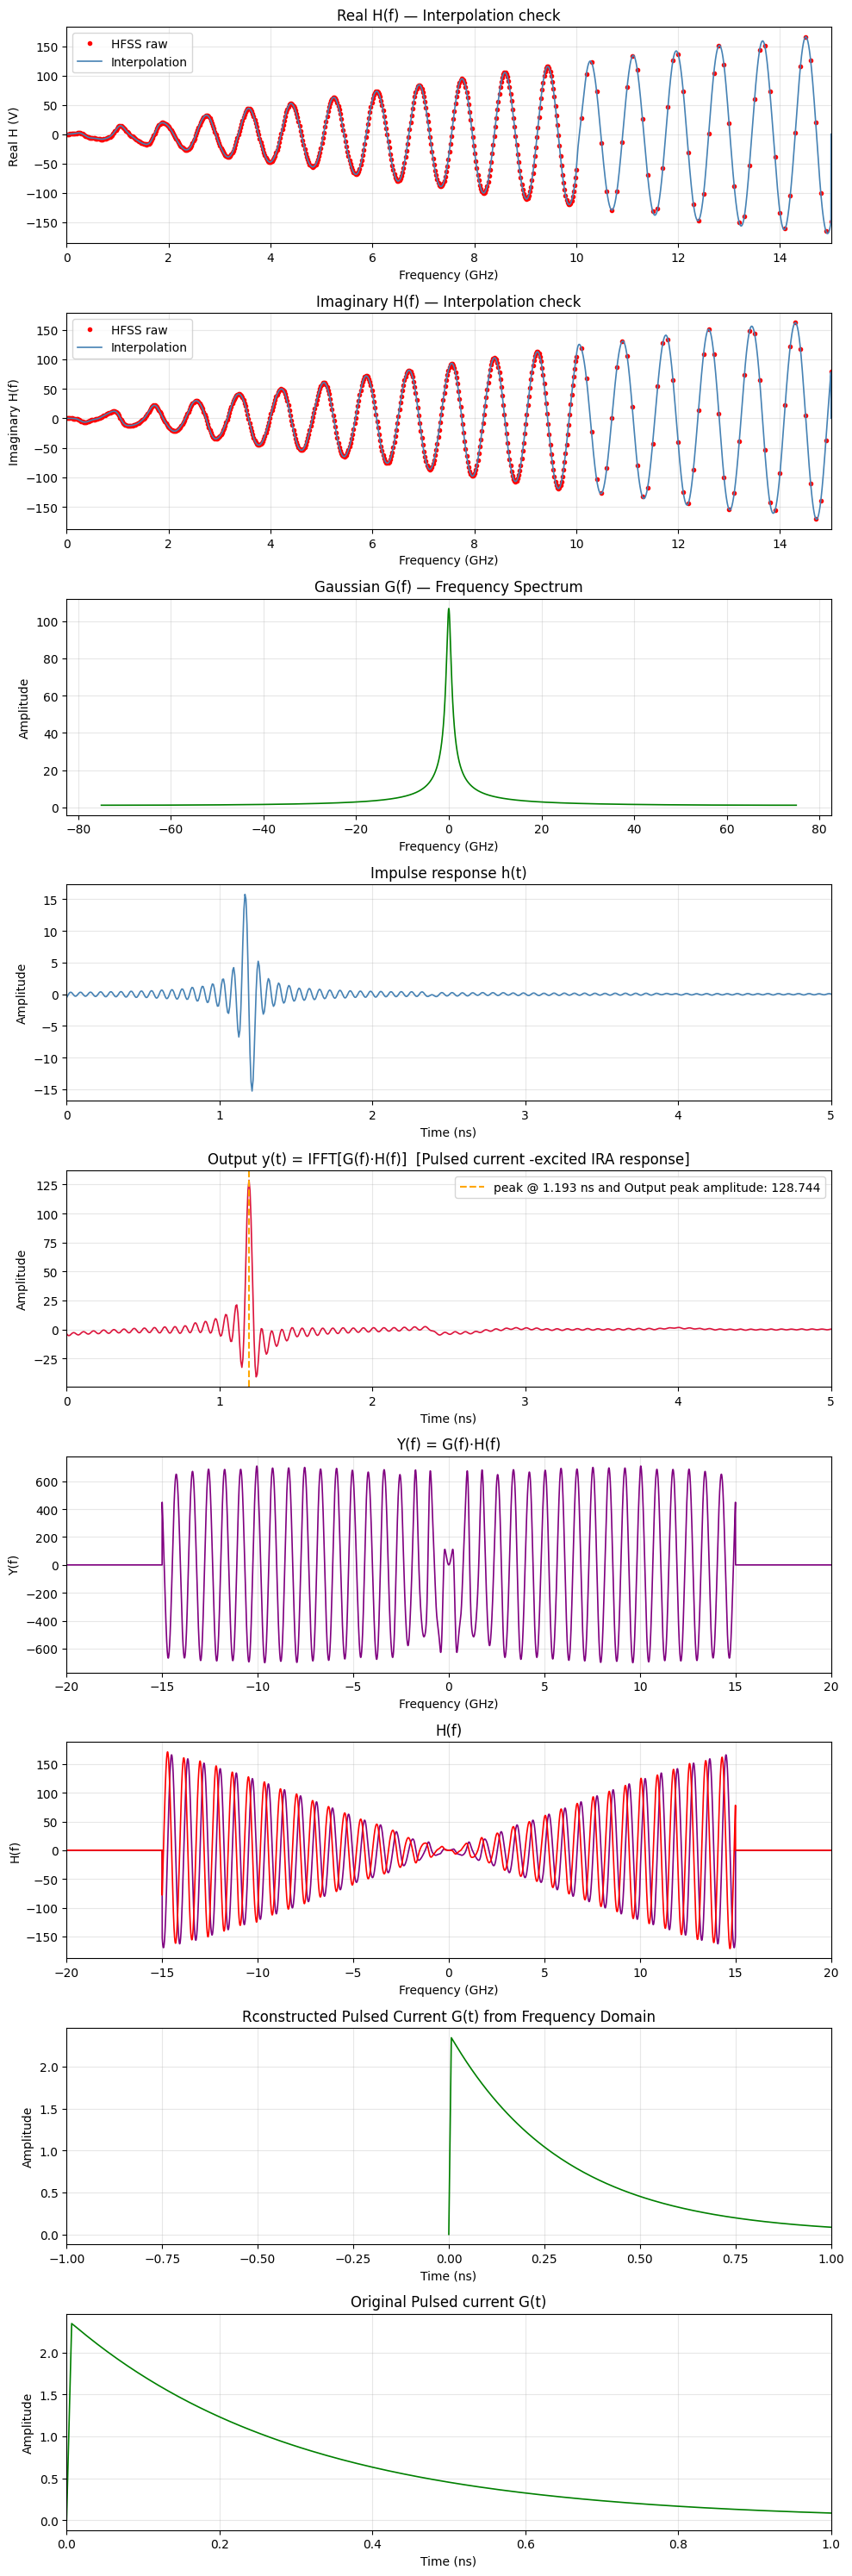

In [2]:
import numpy as np
import pandas as pd
from scipy.interpolate import CubicSpline
from scipy.signal.windows import hann
import matplotlib.pyplot as plt

# ── 1. LOAD HFSS DATA ─────────────────────────────────────────
df = pd.read_csv(r'C:\Shakthi\Shakthi_HFSS\rE Plot 1_server_combined.csv')

freq_raw = df['Freq [GHz]'].values * 1e9
mag_raw  = df['re(rEPhi) [V]'].values
phs_raw  = df['im(rEPhi) [V]'].values

f_min = freq_raw[0]
f_max = freq_raw[-1]
print(f"HFSS band: {f_min/1e6:.1f} MHz → {f_max/1e9:.2f} GHz")

# ── 1. PARAMETERS ─────────────────────────────────────────────
f_center = (f_max + f_min) / 2.0    # ~7.505 GHz

# ── 2. FFT GRID ───────────────────────────────────────────────

N = 2**16

# 1. Define Pulse Parameters
t_rise = 1e-12           # Rise time (1 ps)
t_fall = 300e-12         # Fall time (300 ps)
center_time = 0e-9   # Centered pulse
fs  = 10.0 * f_max           # sampling rate with headroom
dt  = 1.0 / fs
df  = fs / N

t   = (np.arange(N)) * dt     # centered time axis
t_ns  = t * 1e9

# 4. Generate Gaussian Pulse

t1 = np.exp(-t/t_fall)
t2 = np.exp(-t/t_rise)
pulsed_current = (t1-t2)*2.4

gauss_f = np.fft.fft(pulsed_current)
f_freq = np.fft.fftfreq(N, dt)

# ── 3. INTERPOLATE H(f) ONTO FFT GRID ────────────────────────
interp_mag = CubicSpline(freq_raw, mag_raw)
interp_phs = CubicSpline(freq_raw, phs_raw)

mag_H = np.zeros(N)
phs_H = np.zeros(N)
mask_pos = (f_freq >= f_min) & (f_freq <= f_max)
pos_idx  = np.where(mask_pos)[0]

mag_H[mask_pos] = interp_mag(f_freq[mask_pos])
phs_H[mask_pos] = interp_phs(f_freq[mask_pos])


# ── 5. BUILD HERMITIAN H(f) ──────────────────────────────────
H = np.zeros(N, dtype=complex)
H[pos_idx] = mag_H[pos_idx] + 1j * phs_H[pos_idx]

for k in pos_idx:
    if k == 0 or (N % 2 == 0 and k == N // 2):
        continue
    H[-k] = np.conj(H[k])

H[0] = H[0].real
if N % 2 == 0:
    H[N//2] = H[N//2].real

print("Hermitian check:", np.allclose(H[1:N//2], np.conj(H[-1:N//2:-1])))

#Time domain response

G_time = np.fft.ifft(gauss_f)

# ── 7. OUTPUT: Y(f) = G(f) * H(f) → IFFT ────────────────────
Y   = gauss_f * H
y_t = np.fft.ifft(Y)

# ── 8. IMPULSE RESPONSE ──────────────────────────────────────
h_t = np.fft.ifft(H)

peak_idx = np.argmax((y_t))
print(f"Output peak at: {t_ns[peak_idx]:.3f} ns")
print(f"Output peak amplitude: {y_t[peak_idx]:.3f}")

# ── 10. PLOTS ────────────────────────────────────────────────
fig, axes = plt.subplots(9, 1, figsize=(10, 30))

axes[0].plot(freq_raw/1e9, mag_raw, 'o', ms=3, color='red', label='HFSS raw')
axes[0].plot(np.fft.fftshift(f_freq)/1e9, np.fft.fftshift(mag_H), lw=1.2, color='steelblue',label='Interpolation')
axes[0].set_title("Real H(f) — Interpolation check")
axes[0].set_xlabel("Frequency (GHz)"); axes[0].set_ylabel("Real H (V)")
axes[0].set_xlim(0, f_max/1e9); axes[0].legend(); axes[0].grid(True, alpha=0.3)

axes[1].plot(freq_raw/1e9, phs_raw, 'o', ms=3, color='red', label='HFSS raw')
axes[1].plot(np.fft.fftshift(f_freq)/1e9, np.fft.fftshift(phs_H), lw=1.2, color='steelblue',label='Interpolation')
axes[1].set_title("Imaginary H(f) — Interpolation check")
axes[1].set_xlabel("Frequency (GHz)"); axes[1].set_ylabel("Imaginary H(f)")
axes[1].set_xlim(0, f_max/1e9); axes[1].legend(); axes[1].grid(True, alpha=0.3)

axes[2].plot(np.fft.fftshift(f_freq)/1e9,np.fft.fftshift(np.abs(gauss_f)), color='green', lw=1.2)
axes[2].set_title("Gaussian G(f) — Frequency Spectrum")
axes[2].set_xlabel("Frequency (GHz)"); axes[2].set_ylabel("Amplitude")
axes[2].grid(True, alpha=0.3)
# axes[2].set_xlim(-0.1, 0.1)

axes[3].plot(t_ns, h_t, color='steelblue', lw=1.2)
axes[3].set_title("Impulse response h(t)")
axes[3].set_xlabel("Time (ns)"); axes[3].set_ylabel("Amplitude")
axes[3].grid(True, alpha=0.3)
axes[3].set_xlim(0,5)

axes[4].plot(t_ns, y_t, color='crimson', lw=1.2)
axes[4].axvline(t_ns[peak_idx], color='orange', ls='--',label=f'peak @ {t_ns[peak_idx]:.3f} ns and Output peak amplitude: {np.abs(y_t[peak_idx]):.3f}')
axes[4].set_title("Output y(t) = IFFT[G(f)·H(f)]  [Pulsed current -excited IRA response]")
axes[4].set_xlabel("Time (ns)"); axes[4].set_ylabel("Amplitude")
axes[4].set_xlim(0, 5)
axes[4].legend(); axes[4].grid(True, alpha=0.3)

axes[5].plot(np.fft.fftshift(f_freq)/1e9,np.fft.fftshift(Y), color='purple', lw=1.2)
axes[5].set_title("Y(f) = G(f)·H(f)")
axes[5].set_xlabel("Frequency (GHz)"); axes[5].set_ylabel("Y(f)")
axes[5].grid(True, alpha=0.3)
axes[5].set_xlim(-20, 20)

axes[6].plot(np.fft.fftshift(f_freq)/1e9,np.fft.fftshift(H.real), color='purple', lw=1.2, label='real')
axes[6].plot(np.fft.fftshift(f_freq)/1e9,np.fft.fftshift(H.imag), color='red', lw=1.2, label='imaginary')
axes[6].set_title("H(f)")
axes[6].set_xlabel("Frequency (GHz)"); axes[6].set_ylabel("H(f)")
axes[6].grid(True, alpha=0.3)
axes[6].set_xlim(-20, 20)

axes[7].plot(t_ns, G_time, color='green', lw=1.2)
axes[7].set_title("Rconstructed Pulsed Current G(t) from Frequency Domain")
axes[7].set_xlabel("Time (ns)"); axes[7].set_ylabel("Amplitude")
axes[7].grid(True, alpha=0.3)
axes[7].set_xlim(-1,1)

axes[8].plot(t_ns, pulsed_current, color='green', lw=1.2)
axes[8].set_title("Original Pulsed current G(t)")
axes[8].set_xlabel("Time (ns)"); axes[8].set_ylabel("Amplitude")
axes[8].grid(True, alpha=0.3)
axes[8].set_xlim(0,1)


plt.tight_layout()
# plt.savefig("C:\Shakthi\Shakthi_HFSS\IRA_time_domain.png", dpi=1080)
plt.show()